# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

print("Libraries imported successfully.")

Libraries imported successfully.


# Read CSV file

In [3]:
df = pd.read_csv("student_probability_dataset_300.csv")

df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,14.0,69.7,Yes,59.4,Pass
1,11.4,72.4,No,34.3,Fail
2,14.6,85.5,Yes,57.8,Fail
3,18.1,84.1,Yes,51.5,Fail
4,11.1,77.8,No,42.4,Fail


# Calculate Probability of Passing

In [4]:
total_students = len(df)
pass_students = len(df[df["final_exam_pass"] == "Pass"])

p = pass_students / total_students

print("Total Students:", total_students)
print("Students Passed:", pass_students)
print("Probability of Passing (p):", round(p, 4))

Total Students: 300
Students Passed: 210
Probability of Passing (p): 0.7


# Define Random Variable X

In [5]:
from scipy.stats import binom

n = 3

x_values = np.arange(0, n+1)

x_values

array([0, 1, 2, 3])

# Construct Probability Distribution Table

In [6]:
probabilities = binom.pmf(x_values, n, p)

distribution_table = pd.DataFrame({
    "Number_of_Passes (X)": x_values,
    "Probability P(X=x)": probabilities
})

distribution_table

,Number_of_Passes (X),Probability P(X=x)
0,0,0.027
1,1,0.189
2,2,0.441
3,3,0.343


# Verify Total Probability = 1

In [7]:
print("Sum of probabilities:", round(probabilities.sum()))

Sum of probabilities: 1


# Mean and Variance of Random Variable

In [8]:
mean = n * p
variance = n * p * (1 - p)

print("Mean of X:", round(mean, 4))
print("Variance of X:", round(variance, 4))

Mean of X: 2.1
Variance of X: 0.63


# Define Events

In [9]:
A = df[df["study_hours"] > 10]

B = df[df["attendance"] > 80]

A_and_B = df[(df["study_hours"] > 10) & (df["attendance"] > 80)]

only_A = len(A) - len(A_and_B)
only_B = len(B) - len(A_and_B)
both = len(A_and_B)

only_A, only_B, both

(125, 40, 81)

# Draw Venn Diagram

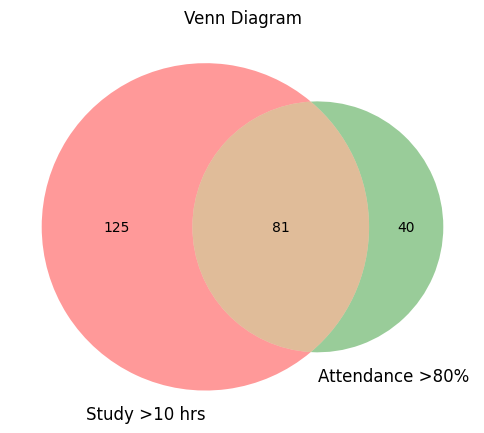

In [10]:
plt.figure(figsize=(6,6))

venn2(
    subsets=(only_A, only_B, both),
    set_labels=("Study >10 hrs", "Attendance >80%")
)

plt.title("Venn Diagram")
plt.show()

# Creating Contingency Table

In [11]:
contingency_table = pd.crosstab(df["group_discussion"], df["final_exam_pass"])
contingency_table

final_exam_pass,Fail,Pass
group_discussion,,
No,37,73
Yes,53,137


# Joint Probability

Joint probability represents the probability of two events occurring together.

Formula:

P(A ∩ B) = Count / Total Students

In [14]:
total_students = contingency_table.values.sum()
total_students

np.int64(300)

In [15]:
joint_yes_pass = contingency_table.loc["Yes","Pass"] / total_students
joint_yes_fail = contingency_table.loc["Yes","Fail"] / total_students
joint_no_pass = contingency_table.loc["No","Pass"] / total_students
joint_no_fail = contingency_table.loc["No","Fail"] / total_students

In [16]:
joint_probability_table = pd.DataFrame({
    "Fail": [joint_no_fail, joint_yes_fail],
    "Pass": [joint_no_pass, joint_yes_pass]
}, index=["No Discussion", "Discussion"])

joint_probability_table

,Fail,Pass
No Discussion,0.123333,0.243333
Discussion,0.176667,0.456667


# Marginal Probability

Marginal probability refers to the probability of a single event occurring.

It is calculated by dividing row or column totals by total students.

In [ ]:
# P(Discussion)
prob_discussion = contingency_table.loc["Yes"].sum() / total_students
prob_no_discussion = contingency_table.loc["No"].sum() / total_students

# P(Pass)
prob_pass = contingency_table["Pass"].sum() / total_students
prob_fail = contingency_table["Fail"].sum() / total_students

print("P(Discussion) =", prob_discussion)
print("P(No Discussion) =", prob_no_discussion)
print("P(Pass) =", prob_pass)
print("P(Fail) =", prob_fail)

P(Discussion) = 0.6333333333333333
P(No Discussion) = 0.36666666666666664
P(Pass) = 0.7
P(Fail) = 0.3


# Conditional Probability

Conditional probability represents the probability of an event occurring given that another event has already occurred.

Formula:

P(A | B) = P(A ∩ B) / P(B)

In [18]:
prob_pass_given_discussion = (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)

prob_pass_given_no_discussion = (
    contingency_table.loc["No","Pass"] /
    contingency_table.loc["No"].sum()
)

print("P(Pass | Discussion) =", prob_pass_given_discussion)
print("P(Pass | No Discussion) =", prob_pass_given_no_discussion)

P(Pass | Discussion) = 0.7210526315789474
P(Pass | No Discussion) = 0.6636363636363637


# Independence Check

Two events are independent if:

P(A ∩ B) = P(A) × P(B)

If not equal, the events are dependent.

In [19]:
print("P(Yes ∩ Pass) =", joint_yes_pass)
print("P(Yes) × P(Pass) =", prob_discussion * prob_pass)

P(Yes ∩ Pass) = 0.45666666666666667
P(Yes) × P(Pass) = 0.4433333333333333


# Bayes Theorem

Bayes Theorem is used to find the conditional probability of an event based on prior knowledge.

Formula:

P(A | B) = (P(B | A) × P(A)) / P(B)

Where:
- A = Student participated in group discussion
- B = Student passed the final exam

We calculate the probability that a student participated in group discussion given that they passed the exam.

In [20]:
# P(Discussion)
prob_discussion = contingency_table.loc["Yes"].sum() / total_students

# P(Pass)
prob_pass = contingency_table["Pass"].sum() / total_students

# P(Pass | Discussion)
prob_pass_given_discussion = (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)

In [21]:
# Bayes Theorem
prob_discussion_given_pass = (
    prob_pass_given_discussion * prob_discussion
) / prob_pass

print("P(Discussion | Pass) =", prob_discussion_given_pass)

P(Discussion | Pass) = 0.6523809523809524


### Conclusion

The result represents the probability that a student participated in group discussion given that they passed the exam.

This shows how prior participation influences the likelihood of passing and helps in understanding the relationship between the two events.